# Geospatial Data Science - EEPS 440/460

# Lecture 25

# High-Performance Computing & Code Optimization

---

### List of other relevant/complementary courses offered at Rice:
- EEPS 435/535: Remote Sensing
- COMP 540: Statistical Machine Learning
- ELEC/COMP 576: Introduction to Deep Learning
- ELEC/COMP 447/546: Intro to Computer Vision
- COMP 422/534:  Parallel Computing

---

# Outline

This session covers profiling, optimization, and parallel processing techniques tailored for large-scale environmental datasets using Python on an HPC cluster.

- Vectorization and JIT Compilation
- Parallelization: Task vs. Data
- Working with Large Geospatial Datasets
- Scaling with Dask
- Running Jobs on SLURM HPC

## Why optimizing your code?
- Processing gigabytes to terabytes of raster or netcdf data
- Memory, I/O, and CPU bottlenecks
- Use profiling to identify bottlenecks hotspots

### There is a reason why we are talking about this last in the semester...

“Premature optimization is the root of all evil (or at least most of it) in programming.” 

Donald Knuth

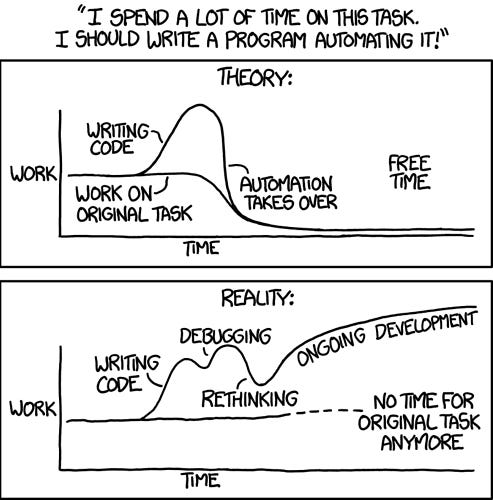

- **Waste of time**: Optimizing code before a performance bottleneck is identified can lead to wasted effort on features that don't significantly impact overall speed. 
- **Decreased readability**: Overly complex code, often resulting from premature optimization, can make it harder to understand and maintain. 
- **Missed priorities**: Focusing on premature optimization can distract from more important tasks, such as ensuring a working solution, meeting deadlines, or addressing user needs. 
- **Potential for unintended consequences**: Optimization can introduce bugs or unexpected behavior, especially if not done carefully and with proper testing. 


# Main approaches to speed up Python code

* Be smart in how you code (review good coding practices)
* Obtaining compiled language speed in Python
* Parallelizing your code

# Let's use the elevation data from Mt. Diablo

In [1]:
%%bash 
gdalwarp -overwrite -r cubic -te -121.97 37.85 -121.88 37.92 -t_srs EPSG:4326 -tr 0.000027777 0.000027777 ../data/3DEP/ned19_n38x00_w122x00_ca_contracostaco_2008.img ../Workspace/tmp.tif
gdalwarp -overwrite -dstnodata -9999 -r cubic -tr 1 1 -t_srs '+proj=aea +lat_1=37.85 +lat_2=37.92 +lat_0=37.885 +lon_0=-121.93 +x_0=0 +y_0=0 +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +units=m +no_defs' ../Workspace/tmp.tif ../Workspace/dem.tif

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Inappropriate ioctl for device


Copying raster attribute table from ../data/3DEP/ned19_n38x00_w122x00_ca_contracostaco_2008.img to new file.
Creating output file that is 3240P x 2520L.
Using internal nodata values (e.g. -3.40282e+38) for image ../data/3DEP/ned19_n38x00_w122x00_ca_contracostaco_2008.img.
Copying nodata values from source ../data/3DEP/ned19_n38x00_w122x00_ca_contracostaco_2008.img to destination ../Workspace/tmp.tif.
Processing ../data/3DEP/ned19_n38x00_w122x00_ca_contracostaco_2008.img [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 7921P x 7769L.
Using internal nodata values (e.g. -3.40282e+38) for image ../Workspace/tmp.tif.
Processing ../Workspace/tmp.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


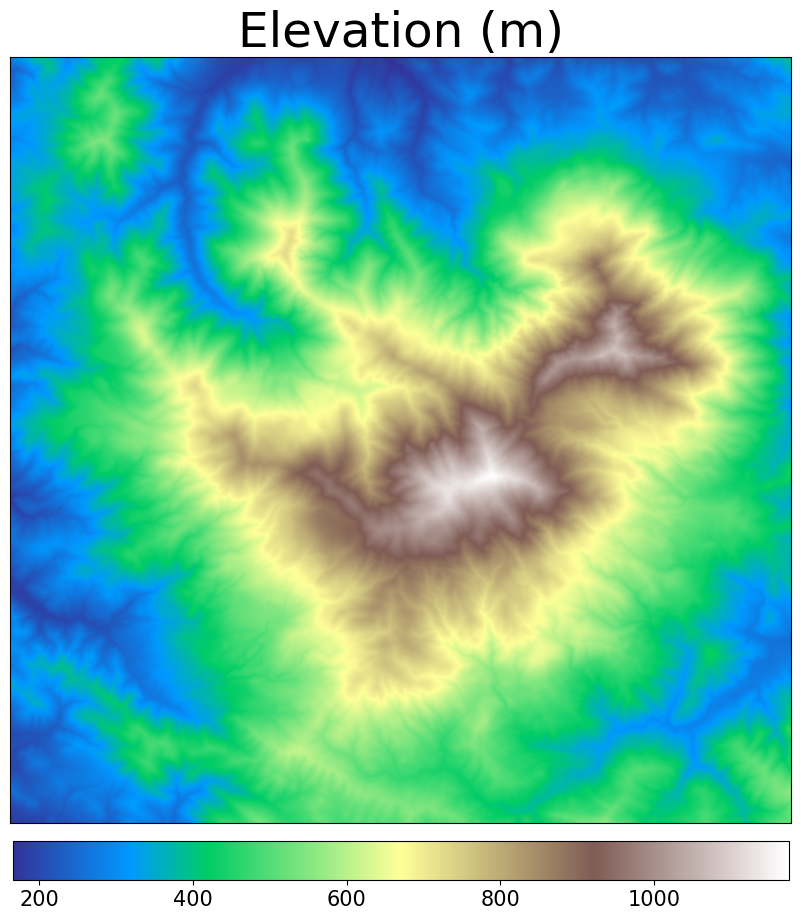

In [2]:
import rasterio
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
dem = rasterio.open('../Workspace/dem.tif').read(1)[10:-10,10:-10]
plt.figure(figsize=(10,10))
plt.imshow(dem,cmap='terrain')
plt.xticks([])
plt.yticks([])
cb = plt.colorbar(orientation='horizontal',shrink=0.8,pad=0.02)
cb.ax.tick_params(labelsize=15)
plt.title('Elevation (m)',fontsize=35)
plt.tight_layout()
plt.show()

In [3]:
print('size of array: %d' % dem.size)

size of array: 61224849


## Calculating a mean (pure python way)

In [4]:
def calculate_mean(data):
    val = 0
    count = 0
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val += data[i,j]
            count += 1
    val = val/count
    return val

In [5]:
#Pure Python
%timeit -n 1 calculate_mean(dem)

6.35 s ± 66.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Vectorization
Vectorization refers to the process of replacing explicit loops in Python with optimized, low-level C or Fortran operations that are applied to entire arrays. 

This is achieved by leveraging NumPy's built-in functions, which are implemented in compiled code and operate on entire arrays at once.


In [6]:
#Numpy
%timeit -n 1 np.mean(dem)

10 ms ± 250 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


2-3 orders of magnitude faster!

### Advantages of Vectorization:
1. **Performance**: Vectorized operations are significantly faster than Python loops because they utilize optimized C/Fortran code under the hood. NumPy achieves this by using instructions and other low-level optimizations, which allow multiple operations to be performed simultaneously.
2. **Readability**: Code written with vectorized operations is often more concise and easier to understand.
3. **Ease of Use**: NumPy provides a rich set of functions that make it easy to perform complex operations on arrays without writing explicit loops.

## But why?

In [7]:
%%HTML
<iframe width="700" height="453" src="https://www.youtube.com/embed/JNMy969SjyU" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>

### Most common compiled languages used in environmental/earth sciences

* C
* C++
* Fortran

NumPy is written in C but compiled as a Python package, thus making the compiled C speed available to Python.

# Bindings

### What is f2py?

`f2py` is a tool provided by the NumPy library that facilitates the integration of Fortran code with Python. 

It allows you to compile Fortran subroutines and functions into Python modules, enabling seamless interaction between Python and Fortran. This makes it possible to call high-performance Fortran code directly from Python, combining the computational efficiency of Fortran with Python's flexibility and ease of use.

`f2py` is particularly valuable for numerical computations, scientific simulations, and workflows that require leveraging existing Fortran libraries or optimizing performance-critical tasks.

In [8]:
%%writefile test_library.f90
subroutine calculate_mean_fortran(data, nx, ny, val)
    integer, intent(in) :: nx, ny
    real, intent(in) :: data(nx, ny)
    real, intent(out) :: val  ! Declare val as an output variable
    integer :: count, i, j

    val = 0.0
    count = 0

    do i = 1, nx
        do j = 1, ny
            val = val + data(i, j)
            count = count + 1
        end do
    end do

    val = val / count
end subroutine calculate_mean_fortran


Overwriting test_library.f90


In [ ]:
%%bash
f2py -c test_library.f90 -m test_library

In [10]:
import test_library
nx = dem.shape[0]
ny = dem.shape[1]
%timeit -n 1 test_library.calculate_mean_fortran(dem,nx,ny)

239 ms ± 15.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Comparison:

* Pure Python: ~6.5 s
* Numpy: 10~ ms
* Compiled Fortran library: ~239 ms

Using a compiled library (and optimized) can lead to big differences in compute time.

## Advantages of f2py

- **Performance**: Fortran is highly optimized for numerical computations, making it faster than pure Python for many tasks.
- **Ease of Integration**: `f2py` simplifies the process of integrating Fortran code with Python, requiring minimal changes to the Fortran code.
- **Reusability**: Existing Fortran libraries can be reused in Python projects without rewriting them.

By using `f2py`, you can combine the computational efficiency of Fortran with the versatility of Python, enabling high-performance scientific computing workflows.

Learn more about f2py here: https://www.youtube.com/watch?v=9nMSKcRimuw

# Similar Approaches for Connecting C/C++/Fortran with Python

There are several tools and libraries available to integrate C, C++, or Fortran code with Python, enabling high-performance computations while maintaining Python's ease of use:

* **Cython**: A superset of Python that allows you to write C extensions for Python. It provides seamless integration with C/C++ code and can significantly speed up Python code by compiling it into C.
* **SWIG**: A tool that generates Python bindings for C and C++ code. It supports multiple languages and is useful for wrapping existing C/C++ libraries.
* **Pybind11**: A lightweight header-only library that simplifies the process of creating Python bindings for C++ code. It is modern and highly flexible.
* **ctypes**: A built-in Python library for calling functions in shared libraries or DLLs written in C.
* **Boost.Python**: A part of the Boost C++ Libraries, it provides tools to create Python bindings for C++ code.

# Applications on Earth System Model Predictions and Simulations

- Leverages Fortran's efficiency in handling large-scale numerical computations, crucial for climate modeling, oceanography, and atmospheric sciences.
- Enables seamless integration of high-performance Fortran code into Python workflows.
- Allows researchers to reuse existing Fortran libraries and models while benefiting from Python's flexibility and rich ecosystem.
- Facilitates faster prototyping, improved collaboration, and integration of legacy code with modern machine learning techniques.

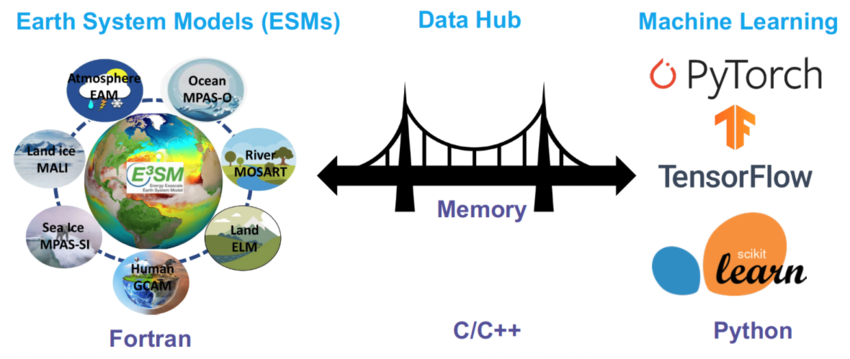

Source: https://doi.org/10.5194/gmd-2024-79


### Integrating AI into Physics-Based Models

- Provides a bridge between high-performance physics simulations and advanced AI frameworks.
- Enables coupling of AI libraries (e.g., TensorFlow, PyTorch) written in C++ with physics-based models.
- Supports hybrid approaches combining data-driven insights with physical laws.
- Enhances simulation accuracy, efficiency, and real-time prediction capabilities.
- Addresses complex challenges like parameter estimation, uncertainty quantification, and anomaly detection.

# However, all of these take time to learn

Wouldn't it be nice if Python just "knew" how to optimize our Python function?

# That's Numba!

Numba is a Just-In-Time (JIT) compiler for Python, designed to optimize numerical computations. It translates Python functions into optimized machine code at runtime using the LLVM compiler infrastructure. Here's how it works:

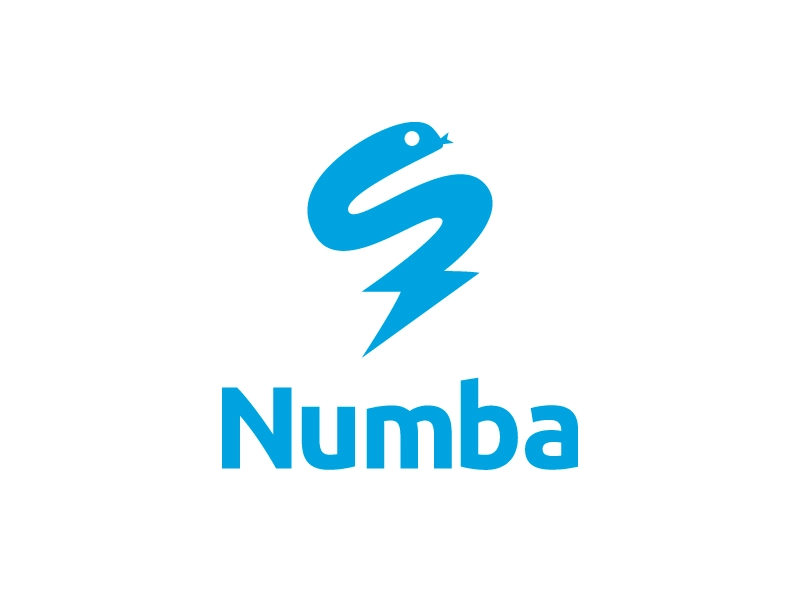


1. **Decorator Usage**:
    - You use the `@numba.njit()` or `@numba.jit()` decorator to mark a Python function for optimization.
    - `@njit` stands for "No Python mode," which avoids Python object overhead and ensures maximum performance.

2. **Compilation**:
    - When the function is called for the first time, Numba compiles it into machine code based on the input data types.
    - This compilation step happens just before execution, hence the term "Just-In-Time."

3. **Optimized Execution**:
    - Subsequent calls to the function use the precompiled machine code, resulting in significant speedups, especially for loops and array operations.

4. **Parallelization**:
    - Numba can also parallelize loops using `numba.prange` and the `parallel=True` option, enabling multi-threaded execution.

5. **Limitations**:
    - Numba works best with numerical computations and array operations.
    - It does not support all Python features, such as dynamic typing or certain standard library functions.

By leveraging Numba, you can achieve near-C performance for numerical tasks while writing code in Python.

# Numba example

In [11]:
import numba
@numba.njit()
def calculate_mean_numba(data):
    val = 0
    count = 0
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val += data[i,j]
            count += 1
    return val/count

In [12]:
#Numba implementation
%timeit -n 1 val = calculate_mean_numba(dem)

The slowest run took 6.86 times longer than the fastest. This could mean that an intermediate result is being cached.
63.4 ms ± 70.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Comparison:

* Pure Python: ~6.5 s
* Numpy: 10~ ms
* Compiled Fortran library: ~239 ms
* Numba: ~63 ms

Using Numba we get *very* close to the Numpy performance. 

### Key Take-away:
If there is an operation that Numpy does not have, if we write using Python code and use Numba, we can reach close to optimal performance.

## So I can use Numba to speed up all my code, right? 

Not really...

Numba will only make a large difference with for loops and array operations (which arguably is already a lot).

Some challenges still remain:

1. **Limited Python Feature Support** for dynamic typing, classes, or certain python standard library functions (e.g., `itertools`, `collections`).

2. **Unsupported Data Types** such as complex Python objects, dictionaries, or strings.

3. **Compilation Overhead** on the first call to a Numba-optimized function, which can be significant for small datasets or functions called only once.

4. **Debugging** Numba-compiled code can be difficult because it runs in machine code, and traditional Python debugging tools may not work.

5. **Parallelization** requires explicit use of `numba.prange` and careful handling of shared resources, and not all algorithms can be easily parallelized.

6. **Memory Management** is not as efficiently as specialized libraries like Dask for very large datasets.

7. **GPU Acceleration** through `numba.cuda` requires knowledge of CUDA programming for NVIDIA GPUs.

8. **No Built-in Support for Distributed memory systems or clusters** such that tools like Dask or MPI are more appropriate.

# Parallelization

Why not just distribute my tasks among many compute cores?

A common laptop now usally comes with 16 cores. 

They also have GPUs which we can also use for parallelization.

We could have spent the entire second half of the course on this topic... So this is not going to be comprehensive at all.

# Why parallelize? Moore's law cannot be sustained

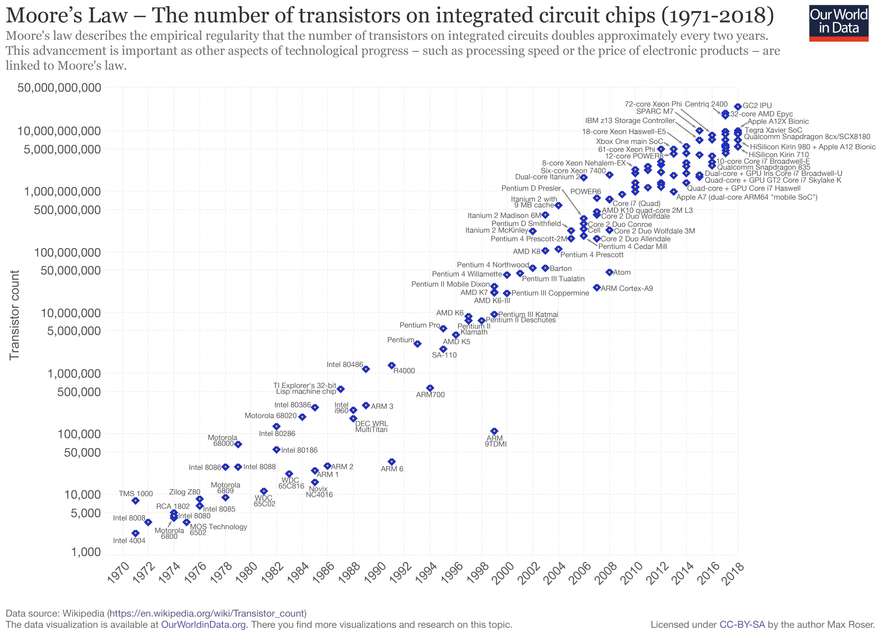

Simply using faster cores, is the easy way to speed up your code by maintining the "serial" aspect of the code while just increasing the execution speed. 

Over the next decade, our ability to continue making faster compute cores will likely start to asymptote (until quantum computing takes over...).

# Alternative? 

Instead of using only one single core replace that with multiple interconnected cores

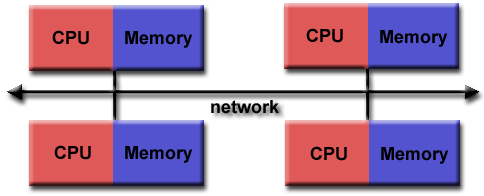

# High performance computing (HPC)

Imagine taking all your laptops and connecting them to create one "single" machine. That is the basics of High Performance Computing.

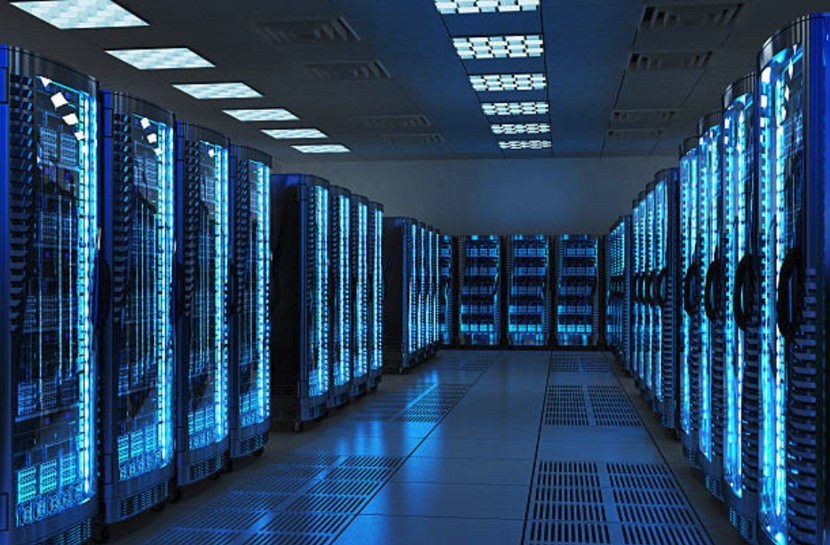

# HPC over the years

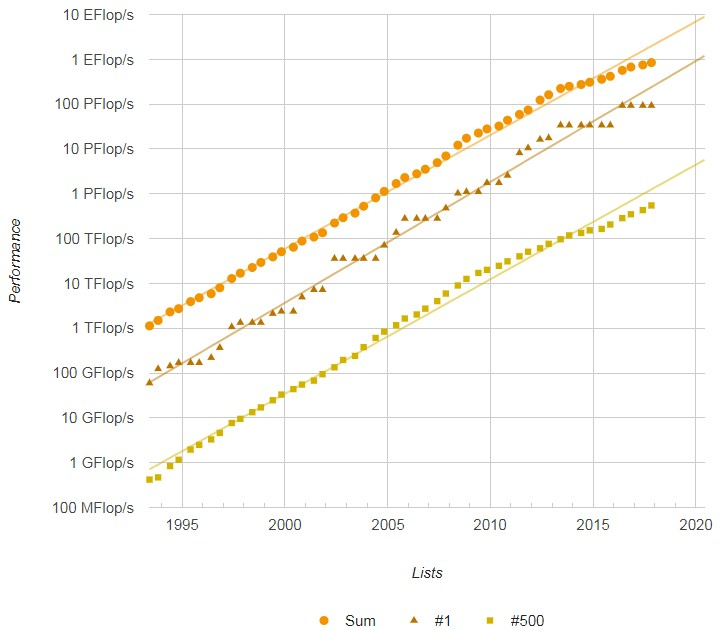

# High Performance Computing: Lots of cores...

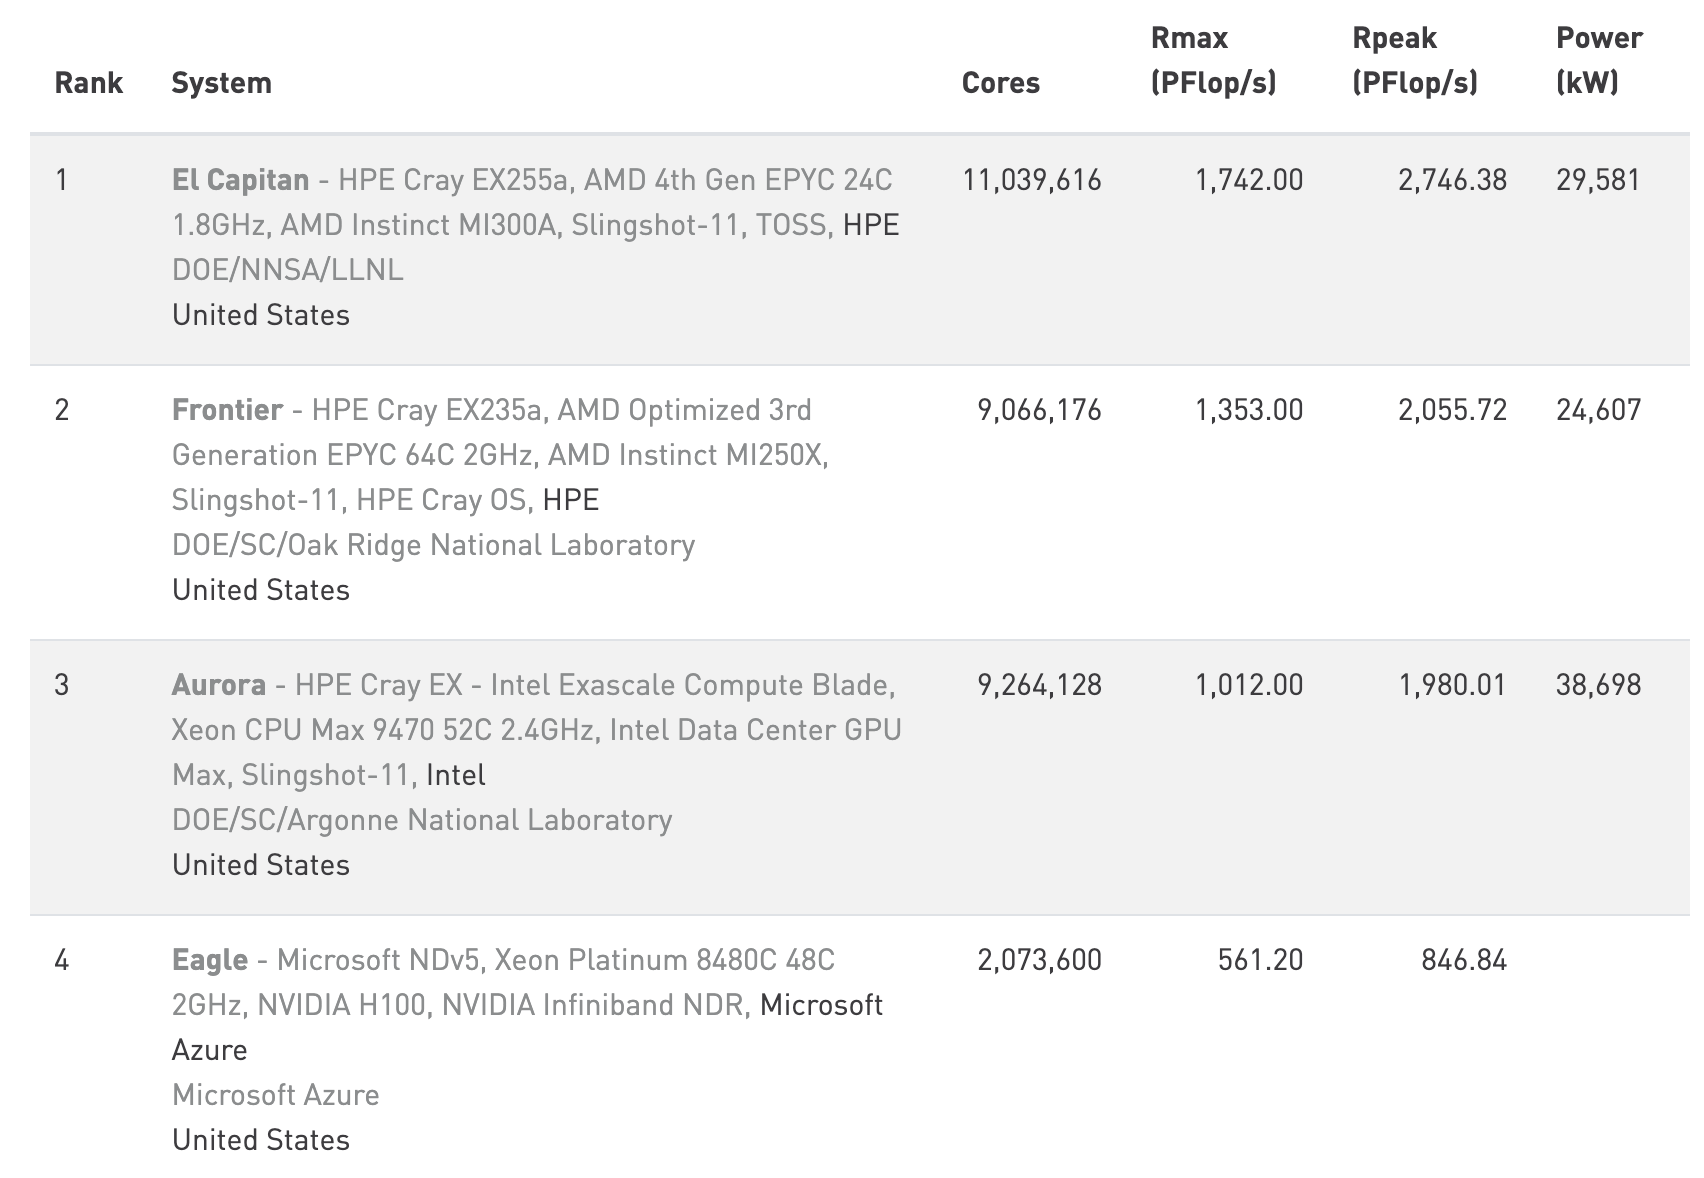

Note: Not all cores all the same

# Shared vs. Distributed memory

# Parallelization approach : Shared memory

This is the type of parallel computing that you have on your laptops/desktops.

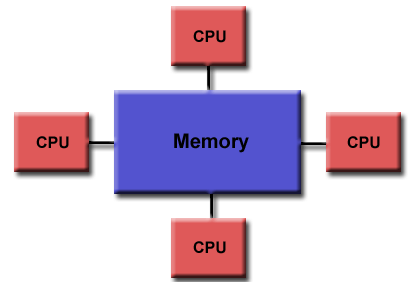

## Shared memory:  OpenMP

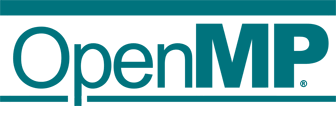

## Shared memory in Python

There are many ways. We are going to explore using Numba (which uses OpenMP under the hood).

In [13]:
print('Number of threads available: %d' % numba.config.NUMBA_NUM_THREADS)

Number of threads available: 14


In [14]:
import numba
@numba.njit(parallel=True)
def calculate_mean_numba_parallel(data):
    val = 0
    count = 0
    for i in numba.prange(data.shape[0]):
        for j in numba.prange(data.shape[1]):
            val += data[i,j]
            count += 1
    return val/count

In [15]:
%timeit -n 1 val = calculate_mean_numba_parallel(dem)

The slowest run took 44.13 times longer than the fastest. This could mean that an intermediate result is being cached.
27.4 ms ± 56.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Comparison:

* Pure Python: ~6.5 s
* Numpy: 10~ ms
* Compiled Fortran library: ~239 ms
* Numba: ~63 ms
* Numba (14 threads): ~27 ms

Using Numba + threading we can get very fast performance. 

# Parallelization approach: Distributed memory

A necessity when moving to 100s+ cores. 

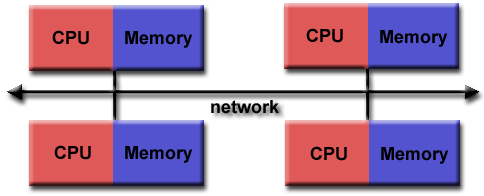

## Distributed memory: MPI

* MPI - Message Passage Interface
* Remains the standard when going to hundreds to millions of cores
* The Google/Amazon/Microsoft world is going to make it obselete in the short term (opinion). 

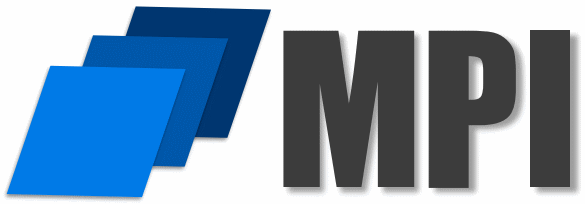

## MPI in Python: mpi4py

In [16]:
%%HTML
<iframe width="806" height="453" src="https://mpi4py.readthedocs.io/en/stable/index.html" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>

# Parallelization approach: Shared + Distributed memory (Hybrid)

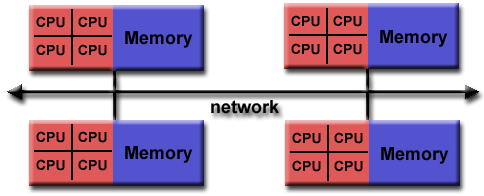

Use `joblib` or `multiprocessing` to parallelize over independent tasks (e.g., raster tiles).

In [17]:
from joblib import Parallel, delayed
import os

# Function to calculate the square of a number and log the core processing it
def calculate_square_with_logging(number):
    core_name = os.getpid()  # Get the process ID
    print(f"Core {core_name} processed number {number}")
    return number ** 2

# Use Parallel to calculate the square of numbers from 1 to 10
numbers = range(1, 11)
squares = Parallel(n_jobs=4)(delayed(calculate_square_with_logging)(num) for num in numbers)

# Print the results
print("Squares:", squares)


Core 33800 processed number 1
Core 33800 processed number 2
Core 33800 processed number 3
Core 33800 processed number 4
Core 33800 processed number 5
Core 33800 processed number 6
Core 33800 processed number 7
Core 33800 processed number 8
Core 33800 processed number 9
Core 33800 processed number 10
Squares: [1, 4, 9, 16, 25, 36, 49, 64, 81, 100]


# Now we are ready for DASK

Dask is a flexible parallel computing library for Python that scales from a single machine to a cluster. 

It is designed to handle large datasets and computations that do not fit into memory.

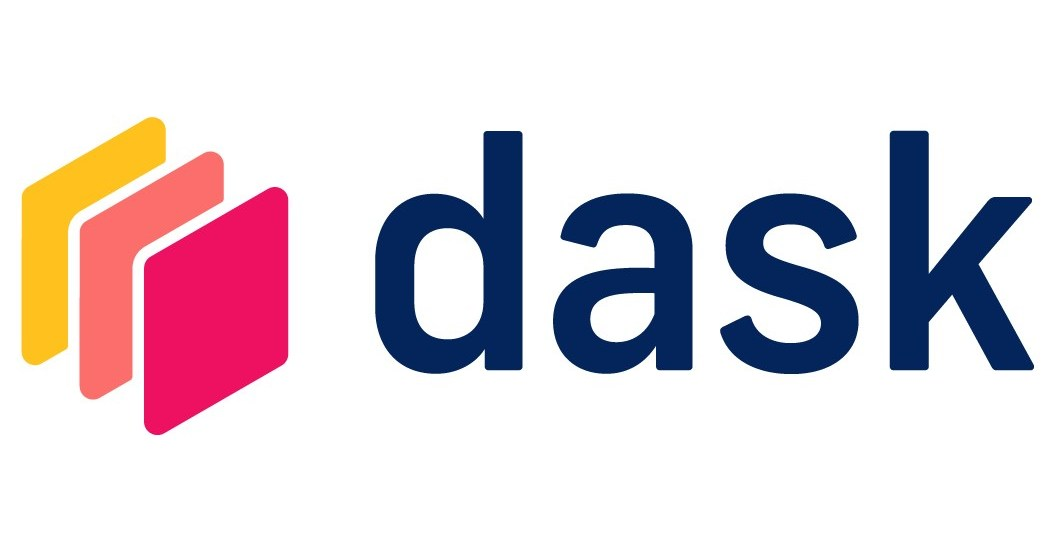

## Key Characteristics of Dask

1. **Scalability**:
    - Dask can scale from a single laptop to a distributed cluster with thousands of cores.
    - It enables seamless transition from local development to large-scale production.

2. **Parallelism**:
    - Dask parallelizes computations across multiple cores or nodes, leveraging both CPUs and GPUs.
    - It supports task-based parallelism and data parallelism.

3. **Lazy Evaluation**:
    - Dask builds a task graph for computations and executes it only when results are explicitly requested.
    - This approach optimizes resource usage and avoids unnecessary computations.

4. **Array and DataFrame Support**:
    - Dask provides parallelized versions of NumPy arrays (`dask.array`) and pandas DataFrames (`dask.dataframe`).
    - These structures allow users to work with datasets that exceed memory limits.

5. **Integration with Python Ecosystem**:
    - Dask integrates well with popular Python libraries like NumPy, pandas, scikit-learn, and Xarray.
    - It supports workflows involving machine learning, geospatial analysis, and more.

6. **Dynamic Task Scheduling**:
    - Dask uses dynamic task scheduling to optimize execution based on available resources.
    - It supports both single-threaded and multi-threaded execution.


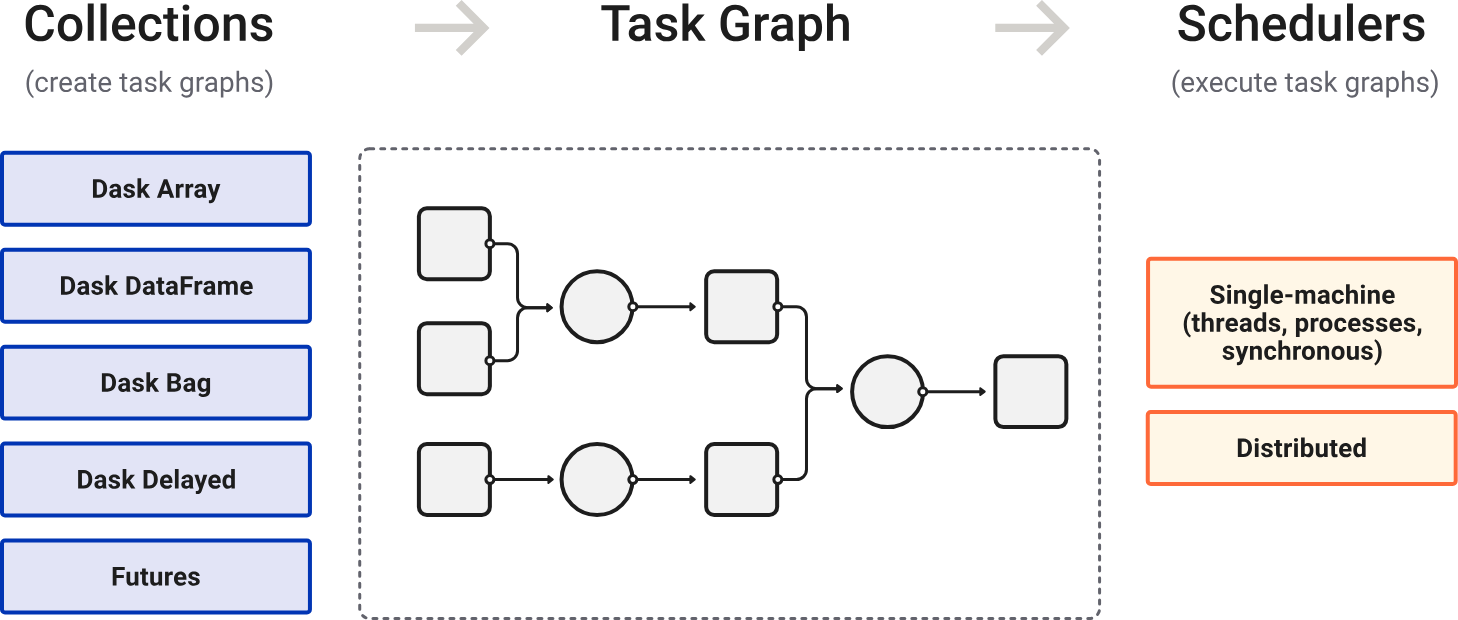

![Optimization GIF](https://miro.medium.com/v2/resize:fit:2000/format:webp/1*MXtMfGFLYzdcPZuY9z7UcQ.gif)

# Example using DASK

In [18]:
#Ask for resources
import dask.distributed
client = dask.distributed.Client(processes=False, threads_per_worker=4,
                n_workers=1, memory_limit='16GB')

In [19]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://168.5.0.117:8787/status,
Dashboard: http://168.5.0.117:8787/status,Workers: 1
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: False
Comm: inproc://168.5.0.117/33728/1,Workers: 1
Dashboard: http://168.5.0.117:8787/status,Total threads: 4
Started: Just now,Total memory: 14.90 GiB
Comm: inproc://168.5.0.117/33728/4,Total threads: 4
Dashboard: http://168.5.0.117:58860/status,Memory: 14.90 GiB
Nanny: None,


In [20]:
# Divide our array among the 8 cores into chunks
import dask.array
dem_dask = dask.array.from_array(dem,chunks=(1000,1000))

In [21]:
dem_dask

dask.array<array, shape=(7749, 7901), dtype=float32, chunksize=(1000, 1000), chunktype=numpy.ndarray>

In [29]:
%timeit -n 1 dem_dask.mean().compute()

7.54 ms ± 2.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Comparison:

* Pure Python: ~6.5 s
* Numpy: 10~ ms
* Compiled Fortran library: ~239 ms
* Numba: ~63 ms
* Numba (14 threads): ~27 ms
* Dask (4 threads, 64 chunks): ~7.5 ms

### Let's try with larger chunk sizes

In [30]:
dem_dask = dask.array.from_array(dem,chunks=(3000,3000))

In [31]:
dem_dask

dask.array<array, shape=(7749, 7901), dtype=float32, chunksize=(3000, 3000), chunktype=numpy.ndarray>

In [32]:
%timeit -n 1 dem_dask.mean().compute()

4.31 ms ± 277 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Comparison:

* Pure Python: ~6.5 s
* Numpy: 10~ ms
* Compiled Fortran library: ~239 ms
* Numba: ~63 ms
* Numba (14 threads): ~27 ms
* Dask (4 threads, 64 chunks): ~7.5 ms
* Dask (4 threads, 9 chunks): ~4.3 ms

In [33]:
client.close()

# Learn More About Dask!

In [34]:
%%HTML
<iframe width="900" height="550" src="https://docs.dask.org/en/stable/10-minutes-to-dask.html" frameborder="0" allow="accelerometer;  autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>

# DASK Parallel Processing on geospatial data

https://knowledge.dea.ga.gov.au/notebooks/Beginners_guide/09_Parallel_processing_with_Dask

# Dask Array: Scaling Up for Terabyte-Level Performance

In [35]:
%%HTML
<iframe width="700" height="400" src="https://www.youtube.com/embed/p_D3W4C5ldg?si=7ZhID62nSTmSGytb" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

# DASK makes parallelization of array operations **REALLY** easy

All these approaches that I have shown use CPUs. Most can be extended to use GPUs as well. 

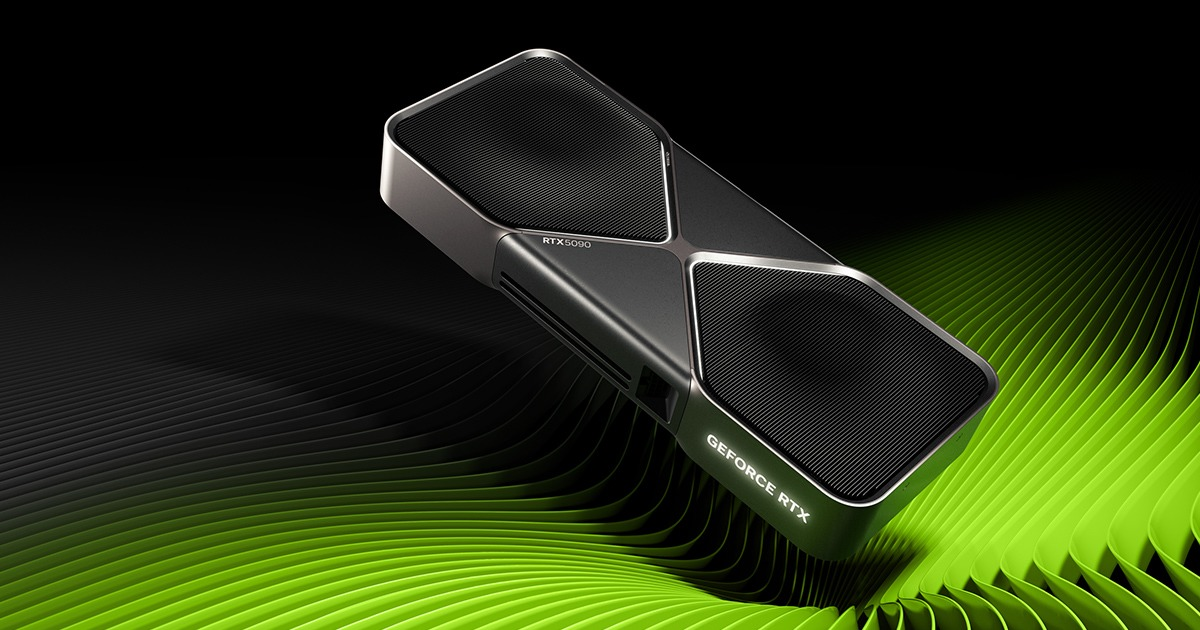

# CPU vs GPU

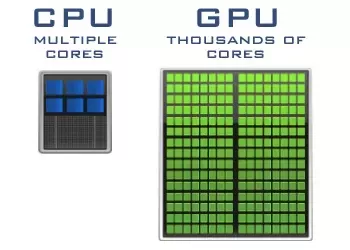

# Do GPUs make a difference?

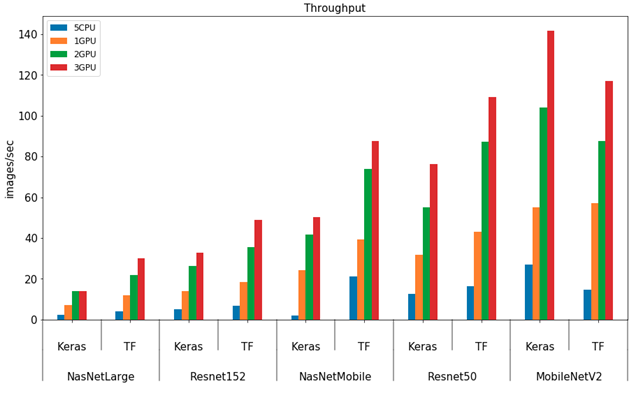

GPUs are playing an increasingly large role in Deep Learning

# Where HPC is heading...

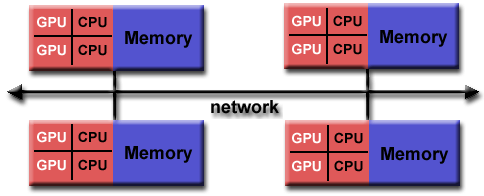

## Final Tips
- Profile first, optimize second
- Prefer vectorization > JIT > multiprocessing > cluster
- Use Dask for large arrays/dataset